# Measuring Time-Series Dataset Similarity using Wasserstein Distance

The Wasserstein distance is used to measure the similarity between two datasets. 
"Measuring Time-Series Dataset Similarity using Wasserstein Distance." (Paper address: https://www.arxiv.org/abs/2507.22189)

This method models the time series dataset as a multivariate normal distribution and uses the Wasserstein similarity metric to measure the distribution distance between datasets, thereby characterizing the similarity or difference between the datasets.

$$
W_p (\mu, \nu) = {\mathrm{min}}_{\gamma \in \Gamma _{\mu, \nu}} \left ( \int \left \| x - y \right \| ^ p \gamma \left ( \mathrm d x, \mathrm d y \right ) \right ) ^ {1/p}
$$

where, $\mu, \nu \in \mathbb R ^ d $ and $\Gamma$ denotes the coupled set of $\mu$ and $\nu$.

This paper focuses on the Wasserstein distance $d_{\mathrm Ws}$ between two multivariate normal distributions $\mathcal D_X$ and $\mathcal D_Y$, which is defined as:

$$
d^2_{\mathrm W _s} \left ( \mathcal D_X, \mathcal D_Y \right ) = \left \| \hat{\mathbf{\mu}}_X - \hat{\mathbf{\mu}}_Y \right \| ^ 2 + \mathrm{tr} \left ( \hat{\mathbf{\Sigma}}_X + \hat{\mathbf{\Sigma}}_Y - 2 \sqrt{\hat{\mathbf{\Sigma}}_X \hat{\mathbf{\Sigma}}_Y} \right )
$$

Where the first term measures the distance between the mean vectors, and the second term captures the difference between the covariance matrices. If two datasets are to be close to each other, they must not only have similar mean vectors, but also similar covariate matrices.

在S2Generator中我们复现了该方法，并且提供了一个接口来计算两个时间序列数据集之间的Wasserstein距离。用户可以通过调用该接口来评估不同时间序列数据集之间的相似性，从而更好地理解和分析它们之间的关系。

同事我们还给出了距离矩阵的可视化函数可以更加直观的展示不同数据集之间的相似性。

In [1]:
import numpy as np
import sys
import os

sys.path.append(os.path.abspath(".."))

from S2Generator.utils import (
    wasserstein_distance,
    wasserstein_distance_matrix,
    plot_wasserstein_heatmap,
)
from S2Generator.utils._wasserstein_distance import time_series_to_distribution

Wasserstein distance需要先根据两个数据集计算出它们的均值向量和协方差矩阵，然后根据上述公式计算出距离值。用户可以通过调整均值向量和协方差矩阵的权重来控制它们在距离计算中的重要性，从而更好地评估不同数据集之间的相似性。

在此我们先生成用于测试的数据$X, Y \in \mathbb{R}^{N \times L}$并计算其多元时间序列的分布。

In [12]:
# Define test data parameters
N1 = 100  # Number of samples in test dataset
N2 = 50
L = 48  # Length of each time series

x = np.random.rand(N1, L)  # First dataset
y = np.random.rand(N2, L)  # Second dataset

# 计算多元时间序列数据集的分布
mean_vector, cov_matrix = time_series_to_distribution(x)

print(mean_vector.shape, cov_matrix.shape)

(48,) (48, 48)


计算时间序列数据集的多元分布是计算Wasserstein距离的第一步，在我们的`wasserstein_distance`函数中进一步整合了计算的完整过程如下所示。

值得注意的是，由于该过程涉及到两个向量的$p$范数的内积运算，因此我们要求两个数据集中采样得到的子序列的长度是相同的。

In [20]:
# 调用该函数来计算距离
distances, mean_value, covar_value = wasserstein_distance(
    x, y, mean_weight=0.5, covar_weight=0.5, return_all=True
)

# 该距离值越小说明两个数据集的分布越接近
print("Wasserstein Distance:", distances)

Wasserstein Distance: 0.2656244233240109


对于多个数据集之间距离的计算，我们可以将多个数据集存储在一个列表中，并使用`wasserstein_distance_matrix`函数来计算它们之间的距离矩阵。最后，我们可以使用`plot_wasserstein_heatmap`函数来可视化距离矩阵，从而更直观地展示不同数据集之间的相似性。

In [19]:
# Generate multiple random datasets
datasets = [np.random.randn(np.random.randint(10, N1), L) for _ in range(6)]
distance_matrix = wasserstein_distance_matrix(
    datasets, mean_weight=0.5, covar_weight=0.5
)

print("Distance Matrix:\n", distance_matrix)

Distance Matrix:
 [[0.         0.34770045 0.27892609 0.29825826 0.27750961 0.29712815]
 [0.34770045 0.         0.29608971 0.30387582 0.30255811 0.29057143]
 [0.27892609 0.29608971 0.         0.22319362 0.22729799 0.23064295]
 [0.29825826 0.30387582 0.22319362 0.         0.22667111 0.21688624]
 [0.27750961 0.30255811 0.22729799 0.22667111 0.         0.18825623]
 [0.29712815 0.29057143 0.23064295 0.21688624 0.18825623 0.        ]]


(<Figure size 1800x1200 with 2 Axes>, <Axes: >)

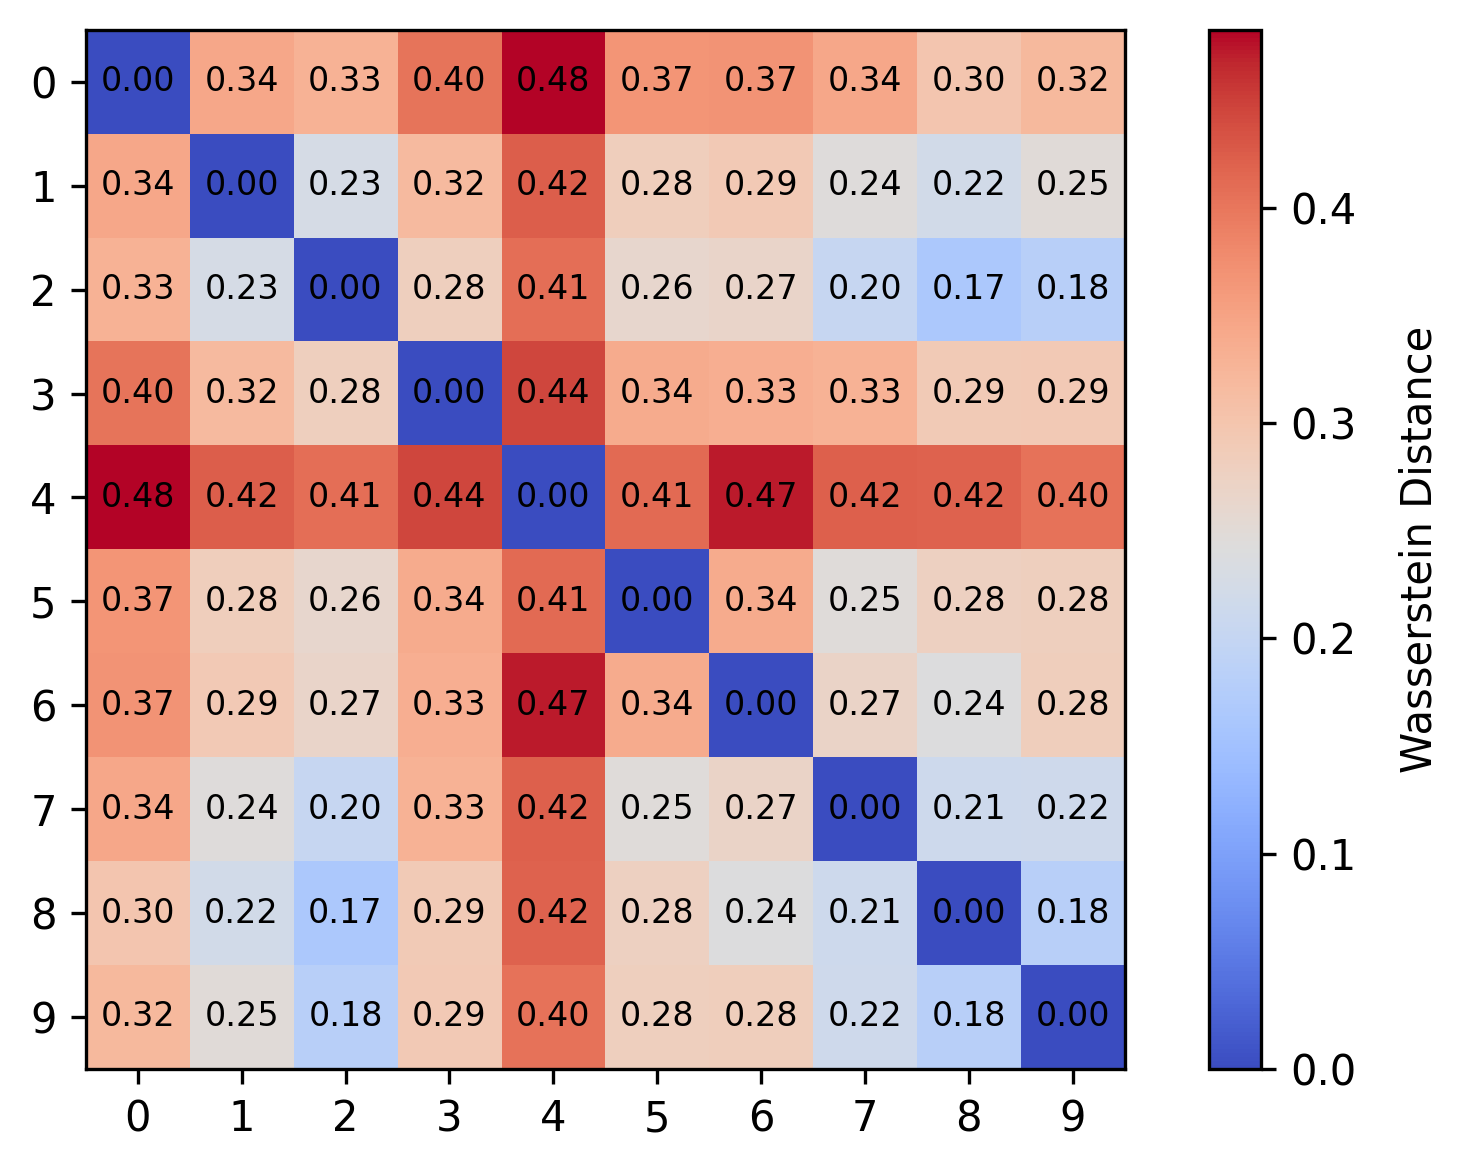

In [17]:
plot_wasserstein_heatmap(distance_matrix=distance_matrix)